# Preparing the critical state of the Transverse-Field Ising Model

The one-dimensional Transverse-Field Ising Model (TFIM) is one of the most studied quantum many-body systems. Its Hamiltonian reads

$$
H_{\text{TFIM}} = J\sum_{\langle i,j\rangle} \sigma^z_i \sigma^z_j \;+\; h\sum_i \sigma^x_i
$$

where $\sigma^\alpha_i$ are the Pauli matrices for $\alpha \in \{x,y,z\}$. At the critical point $h = J$, the system undergoes a quantum phase transition between a anti-ferromagnetic phase ($h < J$) and a paramagnetic phase ($h > J$). The ground state at criticality exhibits long-range entanglement and algebraically-decaying correlations — signatures that make it a demanding benchmark for quantum state preparation.

In this tutorial, we show how to prepare the TFIM critical ground state on a ring of $N = 8$ atoms using **qoolqit**'s Rydberg analog model. We will:

1. Set up a circular register and map the TFIM parameters to Rydberg drive parameters.
2. Design a quasi-adiabatic sweep schedule.
3. Compute the exact ground state via **exact diagonalization** (ED) as a reference.
4. Run the adiabatic preparation with the **`emu_sv`** state-vector backend and compare against the ED target using fidelity, occupation, and correlation functions.


## From the Rydberg Hamiltonian to the Ising model

We start from the Rydberg Hamiltonian with a time-dependent drive, in adimensional units:

$$
H(t) = \sum_{i<j} J_{ij}\, n_i n_j + \sum_i \left[ \frac{\Omega(t)}{2}\sigma^x_i - \delta(t)\, n_i \right],
$$

where $n_i = \tfrac12(I + \sigma^z_i)$ is the Rydberg number operator on atom $i$, $J_{ij} = r_{ij}^{-6}$ is the van der Waals interaction strength, $\Omega(t)$ is the Rabi frequency, and $\delta(t)$ is the detuning.

To connect this to a spin model, we substitute $n_i \to \tfrac12(I+\sigma^z_i)$ everywhere. The interaction term $n_in_j$ expands into an Ising coupling $\sigma^z_i\sigma^z_j$, plus terms linear in each $\sigma^z_i$ (since every atom feels the sum of its interactions with all other atoms), plus a constant. The detuning term similarly splits into a $\sigma^z_i$ piece and a constant. Collecting everything:

$$
H(t) = \sum_{i<j} \frac{J_{ij}}{4}\sigma^z_i\sigma^z_j + \sum_i \left[ \frac{\Omega(t)}{2}\sigma^x_i - \frac{1}{2}\big(\delta(t) - h^z_i\big)\sigma^z_i \right] + \left(\sum_{i<j} \frac{J_{ij}}{4} - \frac{N\delta(t)}{2}\right) I,
$$

where $N$ is the total number of atoms, and

$$
h^z_i \equiv \sum_{j\neq i} \frac{J_{ij}}{2}
$$

is a **residual local longitudinal field**: each atom feels an effective detuning shift coming from its interaction with every other atom in the register. The last term is a global, state-independent energy offset — it contributes only an overall phase to the dynamics, so it can be dropped for state-preparation purposes, but we keep it here explicitly for completeness.

This is precisely the (long-range, site-dependent-field) transverse-field Ising Hamiltonian. Tuning $\Omega(t)$ and $\delta(t)$ lets us drive the system toward the critical point of this Ising model, whose ground state is the target state for this tutorial.

## Setup and imports

We begin by importing the necessary modules. Beyond the core **qoolqit** building blocks (`Drive`, `Register`, `QuantumProgram`, …), we use the `emu_sv` backend which provides exact state-vector propagation — ideal for small systems like $N = 8$ where the full Hilbert space is trivially accessible. For the target ground state, we use `scipy.linalg.eigh` to exactly diagonalize the Rydberg Hamiltonian.


In [66]:
import numpy as np, matplotlib.pyplot as plt, time
from qoolqit import Drive, Interpolated, QuantumProgram, Register, AnalogDevice, DataGraph
from qoolqit.execution import LocalEmulator, Occupation, CorrelationMatrix, EmulationConfig

# emu-sv: exact state-vector backend + observables
from emu_sv import SVBackend, SVConfig, StateResult, Fidelity, StateVector

# Exact diagonalization
from scipy.linalg import eigh
import logging

## Building the Register

We place $N$ atoms on a circle using `DataGraph.circle`, with the nearest-neighbor spacing normalized to $r=1$. Because the Rydberg interaction decays steeply, $J_{ij} = r_{ij}^{-6}$, next-nearest-neighbor couplings are already tiny compared to nearest-neighbor ones. For $N$ atoms on a circle, this ratio has a simple closed form:

$$
\frac{J_{i,i+1}}{J_{i,i+2}} = \big[2\cos(\pi/N)\big]^{6},
$$

which for our $N=8$ register is $\approx 40$ — negligible, and farther neighbors decay even faster. This lets us collapse the all-to-all interaction sum down to nearest neighbors only:

$$
\sum_{i<j} J_{ij}\,\sigma^z_i\sigma^z_j \;\approx\; \sum_i \sigma^z_i \sigma^z_{i+1},
$$

with the periodic identification $\sigma^z_{N+1}\equiv \sigma^z_1$ coming from the circle's closed topology — exactly the nearest-neighbor Ising ring we want, and the natural setting for studying bulk properties of the TFIM.

We can check this directly with `graph.interactions` which returns a dictionary with the value of $J_{ij}$

In [67]:
N = 8
graph = DataGraph.circle(N)

print(graph.interactions()[(0,1)]/graph.interactions()[(0,2)])

39.79898987322333


The mapping from TFIM parameters to Rydberg drive parameters is then:
- **Rabi frequency:** $\Omega(t) \equiv \Omega_R = h/2$, which controls the transverse field.
- **Detuning:** $\delta(t)$, chosen to compensate the residual local longitudinal field $h_i^z = \frac12\sum_{j\neq i} J_{ij}$. We can compute this directly by summing over the `graph.interactions()` dictionary for any qubit — thanks to the ring's translational symmetry, it comes out the same for every qubit. The physical detuning is then simply this constant offset: $\delta(t) = \Delta$.

In [68]:
# TFIM parameters: critical point at h = J = 1
J, h = 1.0, 1.0

# Mapping to Rydberg parameters
OMEGA_R = h / 2  # Rabi frequency

# Residual local detuning due to interactions with neighbors
hz = np.zeros(N)
for i in range(N):
    hz[i] = 0.5 * sum(
        graph.interactions()[(min(i, j), max(i, j))]
        for j in range(N) if j != i
    )
print(f'Local detuning due to interactions: {hz}')

DELTA = hz[0] 

register = Register.from_graph(graph)
device = AnalogDevice()

print(f'N = {N} atoms on a ring')
print(f'Omega = {OMEGA_R:.4f}   delta = {DELTA:.4f}')

Local detuning due to interactions: [1.03174729 1.03174729 1.03174729 1.03174729 1.03174729 1.03174729
 1.03174729 1.03174729]
N = 8 atoms on a ring
Omega = 0.5000   delta = 1.0317


## Designing the quasi-adiabatic schedule

The adiabatic theorem says that if we tune a Hamiltonian slowly enough, a system prepared in the ground state stays in the ground state throughout the sweep. "Slowly enough" means slow compared to the inverse square of the energy gap between the ground and first excited state. 

Near a quantum critical point this gap closes, so a simple **linear** sweep is either wastefully slow everywhere, or not slow enough exactly where the gap is smallest — right at the critical point we care about.

To fix this, we use a **tangent sweep**: the detuning is swept from a large negative value $\delta_0 = -5\,\Omega_R$ up to the target $\delta$ following a $\tan$-shaped profile in time. This naturally slows the sweep down near the critical gap, where the system is most sensitive, and speeds it up everywhere else.

We start at $\delta_0 \ll 0$ which is the ground state of the drive Hamiltonian, the product state $|00\dots0\rangle$ (all atoms in the ground state). This is easy to prepare exactly, giving us a clean, known starting point for the adiabatic sweep.


The full schedule has two phases:
1. **Ramp-up** (first `frac_ramp` of the total time `T`): the Rabi frequency $\Omega(t)$ is smoothly turned on from $0$ to $\Omega_R$, while the detuning stays fixed at $\delta_0$ — this avoids a sudden jump in $\Omega$, which would itself break adiabaticity.
2. **Detuning sweep** (remaining time `T*(1-frac_ramp)`): $\Omega(t)=\Omega_R$ is held constant, and the detuning follows the tangent profile from $\delta_0$ toward $\Delta$, slowing down as it crosses the critical point.

In [69]:
def tangent_sweep(start, target, alpha, n_points):
    """
    Time-warped sweep from `start` to `target` using a tangent map.

    Instead of moving linearly in the normalized fraction s in [0, 1], we
    reparametrize so the sweep slows down near s=1 (the target) — exactly
    where the many-body energy gap is smallest, near the critical point.

    Args:
        start (float): Starting value of the sweep (e.g. the initial detuning d0).
        target (float): Target value the sweep converges to (e.g. DELTA).
        alpha (float): Curvature parameter of the tangent map; larger
            values slow the sweep down more sharply as it approaches
            `target`.
        n_points (int): Number of points used to sample the sweep.

    Returns:
        tuple[np.ndarray, np.ndarray]:
            s (np.ndarray): The normalized fraction along the sweep,
                linearly spaced in [0, 1], with length `n_points`.
            profile (np.ndarray): The corresponding swept values from
                `start` to `target`, following the tangent map, with the
                last point set exactly to `target`.
    """
    s = np.linspace(0.0, 1.0, n_points)
    tan_alpha = np.tan(alpha)
    profile = start + (target - start) * (1.0 - np.tan(alpha * (1.0 - s)) / tan_alpha)
    profile[-1] = target  # avoid floating-point drift; land exactly on target
    return s, profile

def build_program(T, frac_ramp=0.1, alpha=1.4, n_ctrl=81):
    """
    Build the quasi-adiabatic pulse sequence.

    Phase 1 (ramp-up, first `frac_ramp` of T): Omega turns on smoothly from
    0 to OMEGA_R, while the detuning stays fixed at d0 = -5 * OMEGA_R.

    Phase 2 (sweep, remaining time): Omega stays at OMEGA_R, while the
    detuning follows a tangent profile from d0 up to DELTA, slowing down
    as it crosses the critical point.

    Args:
        T (float): Total duration of the pulse sequence.
        frac_ramp (float): Fraction of T spent on the Omega ramp-up phase
            before the detuning sweep begins. Defaults to 0.1.
        alpha (float): Curvature parameter of the tangent sweep; larger
            values slow the sweep down more sharply near the target
            detuning DELTA. Defaults to 1.4.
        n_ctrl (int): Number of control points used to sample the tangent
            sweep during the detuning phase. Defaults to 81.

    Returns:
        QuantumProgram: A program on `register` with an amplitude (Rabi
            frequency) drive that ramps up to OMEGA_R, and a detuning drive
            that holds at d0 then sweeps to DELTA following the tangent
            profile.
    """
    d0 = -5.0 * OMEGA_R  # initial detuning, deep in the far-detuned regime

    # --- Phase 1: Rabi frequency ramp-up --- 
    # from t=0 to t=frac_ramp*T, ramp Omega from 0 to OMEGA_R
    # from t=frac_ramp*T to t=T, hold Omega at OMEGA_R
    omega_times = [0.0, frac_ramp, 1.0]
    omega_values = [0.0, OMEGA_R, OMEGA_R]

    # --- Phase 2: detuning sweep ---
    # Hold at d0 during the ramp-up phase...
    # from t=0 to t=frac_ramp*T, hold detuning at d0
    detuning_times = [0.0, frac_ramp]
    detuning_values = [d0, d0]

    # ...then follow the tangent profile from d0 to DELTA over the rest of the schedule
    # from t=frac_ramp*T to t=T, sweep detuning from d0 to DELTA
    # s is the normalized fraction along the sweep, linearly spaced in [0, 1]
    s, detuning_sweep = tangent_sweep(d0, DELTA, alpha, n_ctrl)
    sweep_times = frac_ramp + s * (1.0 - frac_ramp)

    detuning_times += sweep_times[1:].tolist()
    detuning_values += detuning_sweep[1:].tolist()

    return QuantumProgram(register, Drive(
        amplitude=Interpolated(T, values=omega_values, times=omega_times),
        detuning=Interpolated(T, values=detuning_values, times=detuning_times),
    ))

## Computing the target state with exact diagonalization

Before running the adiabatic preparation, we need a reference ground state to compare against. Since $N = 8$ is small enough, we can build the full Rydberg Hamiltonian at the endpoint parameters $(\Omega, \delta)$ and diagonalize it exactly.

The Rydberg Hamiltonian we diagonalize is

$$
H(\Omega, \delta) = \frac{\Omega}{2}\sum_j \sigma^x_j - \delta \sum_j n_j + \sum_{i<j} U_{ij}\, n_i n_j
$$

where $n_j = |1\rangle\langle 1|$ is the Rydberg number operator. 

The basis convention matches `emu_sv`: site $j$ corresponds to bit $N-1-j$ of the state index (big-endian ordering).


In [112]:
from scipy.sparse import identity, kron, csr_matrix
from scipy.sparse.linalg import eigsh
from functools import reduce 

I2 = identity(2, format="csr", dtype=np.complex128)
SIGMA_X = csr_matrix(np.array([[0, 1], [1, 0]], dtype=np.complex128))
SIGMA_Z = csr_matrix(np.array([[1, 0], [0, -1]], dtype=np.complex128))
N_OP    = csr_matrix(np.diag([0.0, 1.0]).astype(np.complex128))

def local_operator(op, site, N):
    """
    Embed a single-site operator `op` acting on `site` into the full
    2^N-dimensional Hilbert space.
    Args:
        op (scipy.sparse matrix): 2x2 single-site operator.
        site (int): Index of the site `op` acts on, in [0, N).
        N (int): Total number of sites.

    Returns:
        scipy.sparse.csr_matrix: The (2**N, 2**N) embedded operator.
    """
    ops = [I2] * N
    ops[site] = op
    return reduce(kron, ops)  # kron(I2, I2, ..., op, ..., I2)

def build_target_hamiltonian(N, graph, omega, delta):
    """
    Build the sparse 2^N x 2^N Rydberg Hamiltonian:
        H = sum_j [ (omega/2) sigma^x_j - delta n_j ] + sum_{i<j} J_ij n_i n_j
    using Kronecker products of local operators.
    Args:
        N (int): Number of atoms/sites.
        graph: The register/graph object, providing `graph.interactions()`
            as a dict mapping (i, j) with i < j to J_ij.
        omega (float): Rabi frequency driving sigma^x on every site.
        delta (float): Detuning driving -n_i on every site.
    Returns:
        scipy.sparse.csr_matrix: The (2**N, 2**N) complex Hamiltonian.
    """
    dim = 2 ** N

    n_ops = [local_operator(N_OP, j, N) for j in range(N)]
    x_ops = [local_operator(SIGMA_X, j, N) for j in range(N)]

    # Drive terms: (omega/2) sigma^x_j - delta n_j, summed over all sites.
    H = csr_matrix((dim, dim), dtype=np.complex128)
    for j in range(N):
        H = H + 0.5 * omega * x_ops[j] - delta * n_ops[j]

    # Interaction terms: J_ij n_i n_j, summed over all pairs i < j, read
    # directly from the graph's interactions dict.
    for (i, j), val in graph.interactions().items():
        H = H + val * (n_ops[i] @ n_ops[j])
    return H.tocsr()

# Diagonalize the target Hamiltonian (only the two lowest eigenpairs are needed)
# We use the value of DELTA and OMEGA_R that correspond to the critical point of the TFIM,
# The ground state of H_target is the critical state we want to prepare.
H_target = build_target_hamiltonian(N, graph, OMEGA_R, DELTA)
evals, evecs = eigsh(H_target, k=2, which="SA")
order = np.argsort(evals)
evals, evecs = evals[order], evecs[:, order]
psi_gs = evecs[:, 0].astype(np.complex128)
print(f"E_0 = {evals[0]:.6f},  E_1 = {evals[1]:.6f},  gap = {evals[1] - evals[0]:.6f}")

E_0 = -4.602978,  E_1 = -4.546047,  gap = 0.056931


In [113]:
def build_TFIM_hamiltonian(N, h):
    """
    Build the sparse 2^N x 2^N transverse-field Ising Hamiltonian:
        H = sum_{i=1}^{N-1} sigma^z_i sigma^z_{i+1} + h sum_{i=1}^N sigma^x_i

    Args:
        N (int): Number of spins.
        h (float): Transverse field strength.

    Returns:
        scipy.sparse.csr_matrix: The (2**N, 2**N) complex Hamiltonian.
    """
    dim = 2 ** N
    z_ops = [local_operator(SIGMA_Z, j, N) for j in range(N)]
    x_ops = [local_operator(SIGMA_X, j, N) for j in range(N)]

    # Interaction terms: sum_{i=1}^{N-1} sigma^z_i sigma^z_{i+1}
    H = csr_matrix((dim, dim), dtype=np.complex128)
    for i in range(N - 1):
        H = H + z_ops[i] @ z_ops[i + 1]

    # Transverse field terms: h sum_{i=1}^N sigma^x_i
    for j in range(N):
        H = H + h * x_ops[j]

    return H.tocsr()

H_TFIM = build_TFIM_hamiltonian(N, h)
evals, evecs = eigsh(H_TFIM, k=2, which="SA")
order = np.argsort(evals)
evals, evecs = evals[order], evecs[:, order]

# Fidelity between the ground state of the TFIM and the target Hamiltonian
psi_TFIM_gs = evecs[:, 0].astype(np.complex128)
fidelity = np.abs(np.vdot(psi_TFIM_gs, psi_gs)) ** 2
print(f"Fidelity between TFIM ground state and target ground state: {fidelity:.6f}")

Fidelity between TFIM ground state and target ground state: 0.916026


From the ED ground state we can directly compute the target occupation $\langle n_i \rangle$ and the correlation matrix $\langle n_i n_j \rangle$ for later comparison.


In [114]:
def occupation_and_corr_from_psi(psi):
    """
    Compute <n_i> and <n_i n_j> from a dense state vector, reusing the same
    local number operators used to build the Hamiltonian. Each n_ops[j] is
    diagonal, so its diagonal directly gives the occupation of site j for
    every basis state -- no need to recompute bits separately.
    """
    n_ops = [local_operator(N_OP, j, N) for j in range(N)]
    occ_per_state = np.stack([op.diagonal() for op in n_ops], axis=1)  # (dim, N)
    p = np.abs(psi) ** 2
    occ = occ_per_state.T @ p
    corr = np.einsum('ki,kj,k->ij', occ_per_state, occ_per_state, p)
    return occ.real, corr.real


occ_t, corr_t = occupation_and_corr_from_psi(psi_gs)
conn_t = corr_t - np.outer(occ_t, occ_t)  # Connected correlations

print(f'Target <n> = {np.mean(occ_t):.4f}')

Target <n> = 0.5000


## Running the adiabatic state preparation

We now run the actual time-evolution under the quasi-adiabatic schedule using the **`emu_sv`** backend (exact state-vector propagation). We request the occupation, correlation matrix, fidelity against the ED ground state, and the final state vector.

To pass the ED ground state as a fidelity reference, we convert it to an `emu_sv.StateVector` object using the `'g'`/`'r'` eigenstates convention.


In [116]:
# Convert the ED ground state to an emu_sv StateVector for the Fidelity observable
n_ops = [local_operator(N_OP, j, N) for j in range(N)]

occ_per_state = np.stack([op.diagonal() for op in n_ops], axis=1).astype(int)  # (dim, N)
GR = np.array(['g', 'r'])
labels = [''.join(row) for row in GR[occ_per_state]]

amplitudes = dict(zip(labels, psi_gs.astype(complex)))
target_state = StateVector.from_state_amplitudes(
    eigenstates=('g', 'r'), amplitudes=amplitudes
)

/var/folders/45/8z7_vyh51fxdgx80qfhf8dnw0000gp/T/ipykernel_61930/4265710877.py:4: ComplexWarning: Casting complex values to real discards the imaginary part
  occ_per_state = np.stack([op.diagonal() for op in n_ops], axis=1).astype(int)  # (dim, N)


In [127]:
# Configure observables
config = EmulationConfig(
    observables=(
        Occupation(evaluation_times=[1.0]),
        CorrelationMatrix(evaluation_times=[1.0]),
        Fidelity(evaluation_times=[1.0], state=target_state),
        StateResult(evaluation_times=[1.0]),
    ),
    log_level=logging.WARN
)

T_list = np.linspace(0.1, 1, 31) # Total evolution time for the adiabatic sweep
fidelity = np.zeros((2, len(T_list))) # Store the fidelity with respect to each target state for each T
for i, T in enumerate(T_list):
    # Build and compile the program
    prog = build_program(T)
    prog.compile_to(device, device_max_duration_ratio=T)

    # Run the adiabatic evolution
    emulator = LocalEmulator(backend_type=SVBackend, emulation_config=config)
    results = emulator.run(prog)

    # Extract results
    tagged = results[0].get_tagged_results()

    psi_T = tagged['state'][-1].data.cpu().numpy().astype(np.complex128)

    fidelity[0, i] = abs(np.vdot(psi_T, psi_gs))**2
    fidelity[1, i] = abs(np.vdot(psi_T, psi_TFIM_gs))**2

occ_p  = np.asarray(tagged['occupation'][-1]).real
corr_p = np.asarray(tagged['correlation_matrix'][-1]).real
conn_p = corr_p - np.outer(occ_p, occ_p)
fid    = float(np.asarray(tagged['fidelity'][-1]).real)

## Comparison plots

We now compare the prepared state against the ED target across several observables:

- **Fidelity**: overlap with the exact ground state.
- **Rydberg density** $\langle n_i \rangle$: at the critical point, this should be close to $1/2$ for all sites.
- **Connected correlations** $C_{\text{conn}}(d) = \langle n_i n_{i+d}\rangle - \langle n_i\rangle\langle n_{i+d}\rangle$: these should decay algebraically at criticality.
- **Staggered correlations** $(-1)^d C_{\text{conn}}(d)$: reveal antiferromagnetic ordering tendencies.


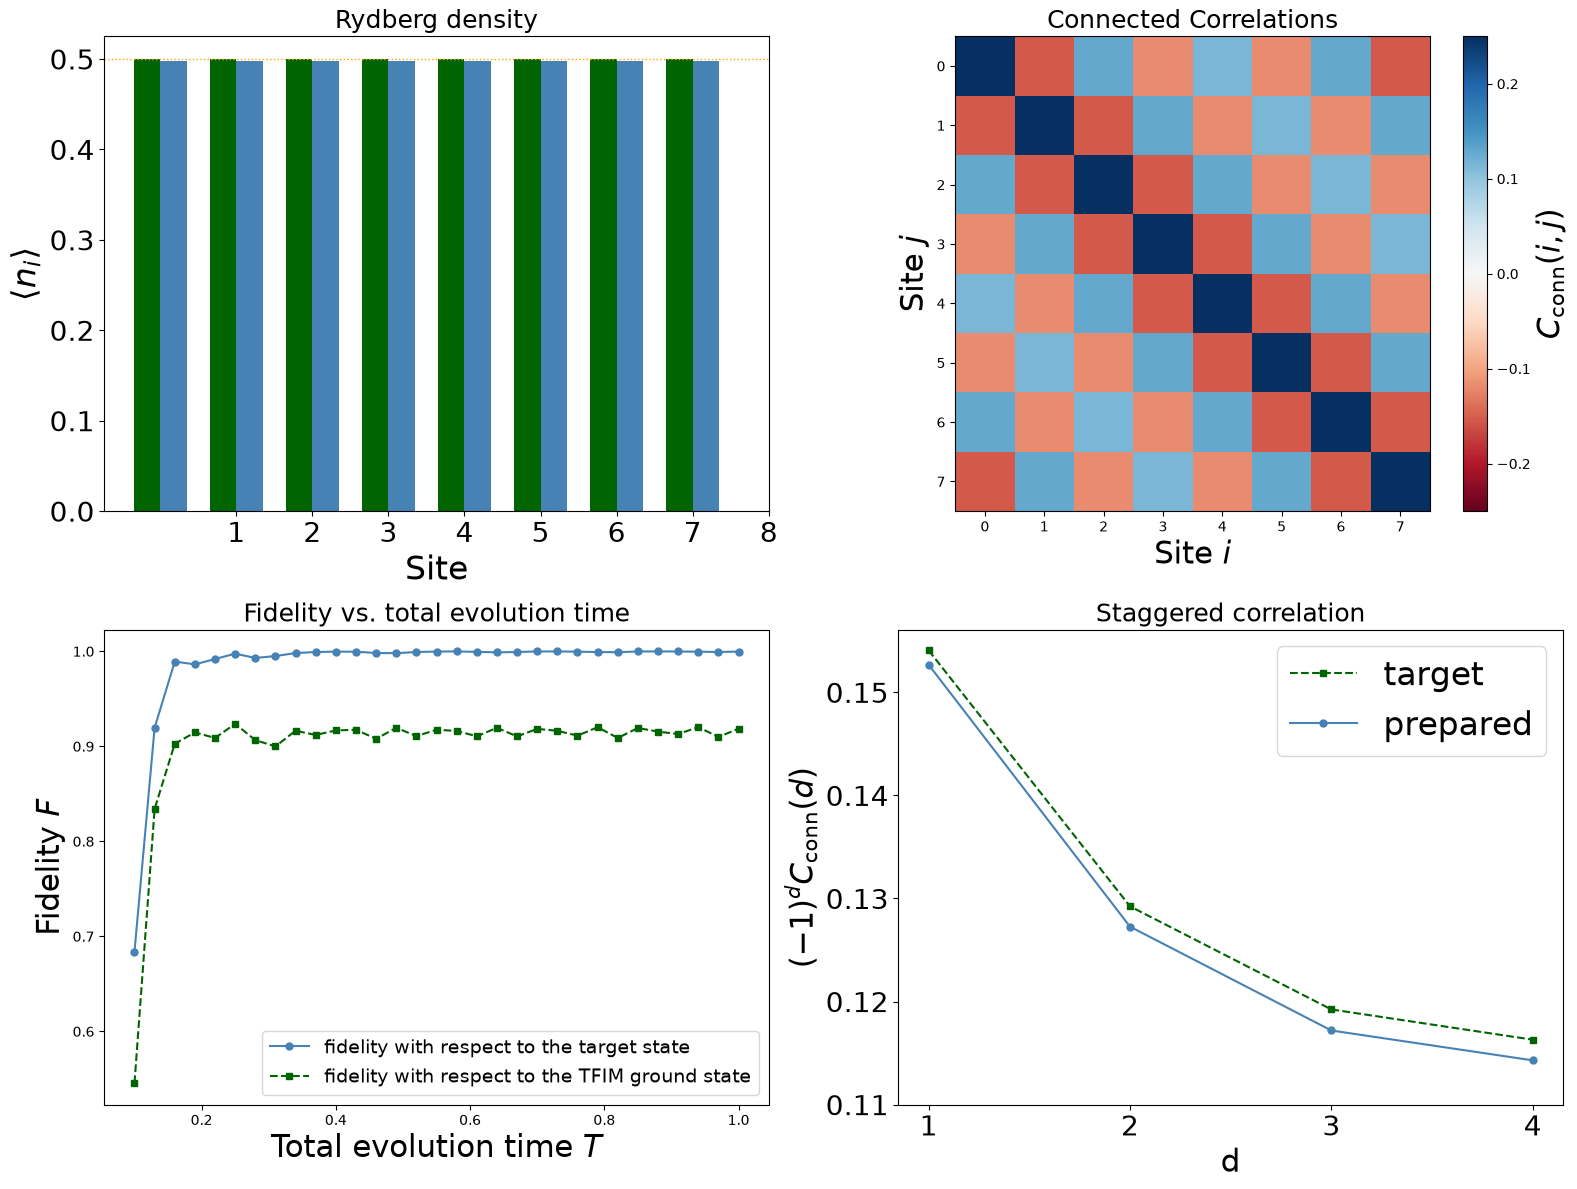

In [128]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Rydberg density ---
ax = axes[0,0]
x = np.arange(N)
y = [round(x,2) for x in np.arange(0,0.55,0.1)]
w = 0.35
ax.bar(x - w/2, occ_t, w, color='darkgreen', label='target')
ax.bar(x + w/2, occ_p, w, color='steelblue', label='prepared')
ax.axhline(0.5, color='orange', ls=':', lw=1, label=r'$\langle n\rangle=1/2$')
ax.set_xlabel('Site',size=24)
ax.set_ylabel(r'$\langle n_i \rangle$',size=24)
ax.set_xticks(x+1,x+1,size=20)
ax.set_yticks(y,y,size=20)
ax.set_title('Rydberg density',size=18)

# --- Connected correlations ---
ax = axes[0,1]
ax.imshow(conn_p, cmap='RdBu', vmin=-0.25, vmax=0.25)
ax.set_xlabel('Site $i$', fontsize=22)
ax.set_ylabel('Site $j$', fontsize=22)
ax.set_title('Connected Correlations', fontsize=18)
# Add the colorbar
cbar = plt.colorbar(ax.images[0], ax=ax)
cbar.set_label(r'$C_{\mathrm{conn}}(i,j)$', fontsize=22)

# --- Fidelity vs. total evolution time ---
ax = axes[1,0]
ax.plot(T_list, fidelity[0,:], 'o-', color='steelblue', ms=5, label='fidelity with respect to the target state')
ax.plot(T_list, fidelity[1,:], 's--', color='darkgreen', ms=5, label='fidelity with respect to the TFIM ground state')

ax.set_xlabel('Total evolution time $T$',size=22)
ax.set_ylabel('Fidelity $F$',size=22)
ax.legend(fontsize=14)

ax.set_title('Fidelity vs. total evolution time',size=18)

# --- Staggered correlations ---
ax = axes[1,1]
max_d = N // 2
dists = np.arange(1, max_d + 1)
stag_t = np.array([(-1)**d * np.mean([conn_t[i, (i+d) % N] for i in range(N)]) for d in dists])
stag_p = np.array([(-1)**d * np.mean([conn_p[i, (i+d) % N] for i in range(N)]) for d in dists])
ax.plot(dists, stag_t, 's--', color='darkgreen', ms=5, label='target')
ax.plot(dists, stag_p, 'o-',  color='steelblue', ms=5, label='prepared')
ax.set_xlabel('d',size=22)
ax.set_ylabel(r'$(-1)^d C_{\mathrm{conn}}(d)$',size=22)
x = range(1,N//2+1)
y = [round(x,2) for x in np.arange(0.11,0.155,0.01)]
ax.set_xticks(x,x,size=20)
ax.set_yticks(y,y,size=20)
ax.set_title('Staggered correlation',size=18)
ax.legend(fontsize=24)

plt.tight_layout()
plt.show()

## Conclusion

We successfully prepared the critical ground state of the 1D Transverse-Field Ising Model on a ring of 8 atoms using a quasi-adiabatic tangent sweep in **qoolqit**'s Rydberg analog model. The high fidelity with the ED target confirms that the schedule is effective even near the critical point where the energy gap is small.